In [1]:
# ============================================
#  EDA & VISUALIZATIONS
# ============================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load master dataset
master = pd.read_csv('data/master_dataset.csv')

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print(f"✅ Master dataset loaded: {master.shape}")
print(master.head(3))

✅ Master dataset loaded: (52922, 18)
   TransactionId  UserId  VisitYear  VisitMonth  VisitModeId  AttractionId  \
0              3   70456       2022          10            2           640   
1              8    7567       2022          10            4           640   
2              9   79069       2022          10            3           640   

   Rating  ContinentId  RegionId  CountryId  CityId   CityName  \
0       5            5        21        163    4341  Guildford   
1       5            2         8         48     464    Ontario   
2       5            2         9         54     774     Brazil   

          Country            Region Continent                      Attraction  \
0  United Kingdom    Western Europe    Europe  Sacred Monkey Forest Sanctuary   
1          Canada  Northern America   America  Sacred Monkey Forest Sanctuary   
2          Brazil     South America   America  Sacred Monkey Forest Sanctuary   

            AttractionType VisitModeName  
0  Nature & Wildl

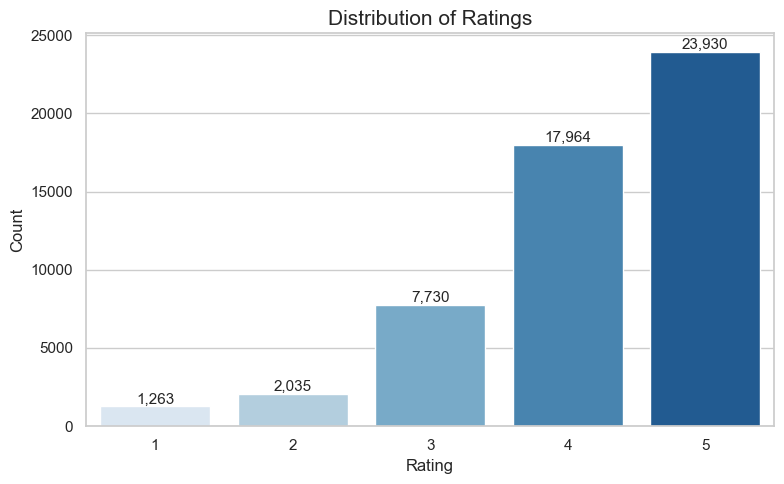

✅ Plot 1 saved!


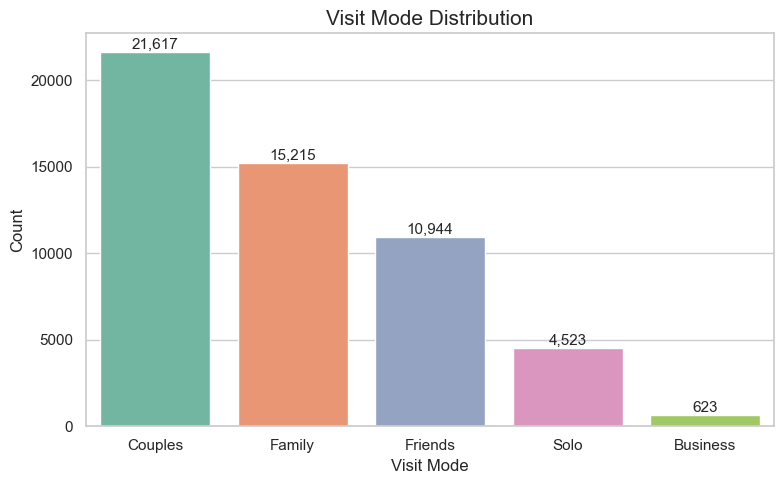

✅ Plot 2 saved!


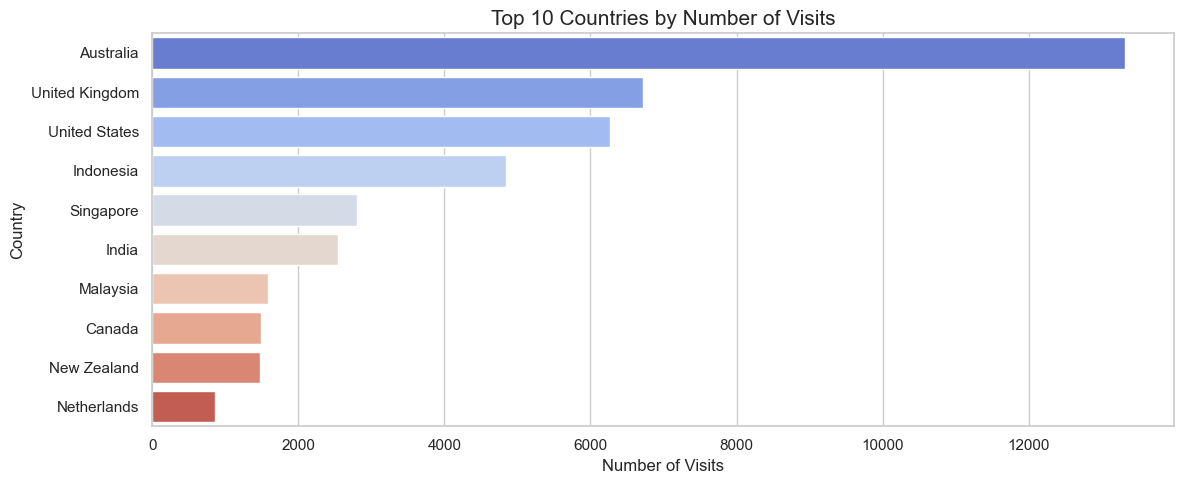

✅ Plot 3 saved!


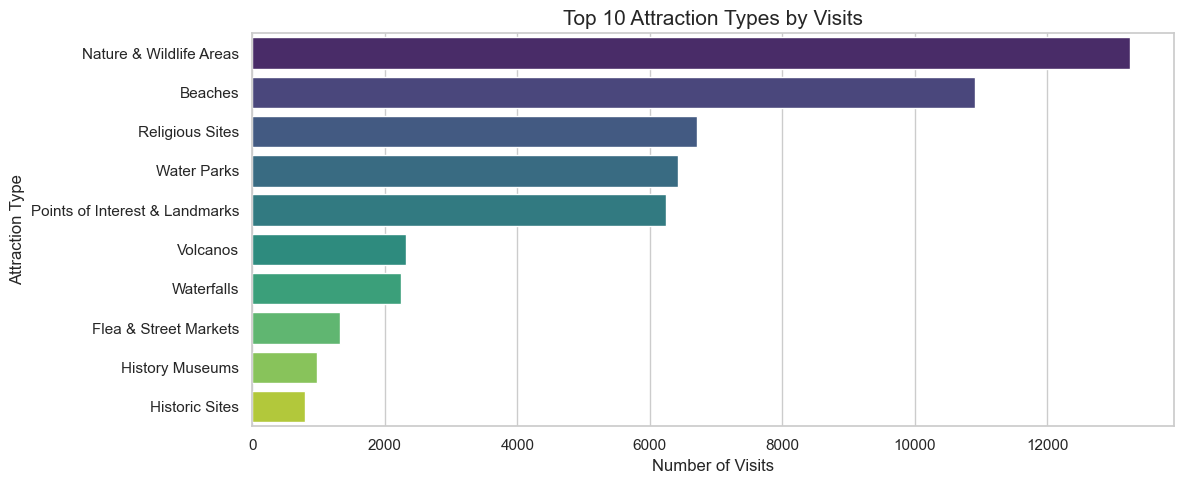

✅ Plot 4 saved!


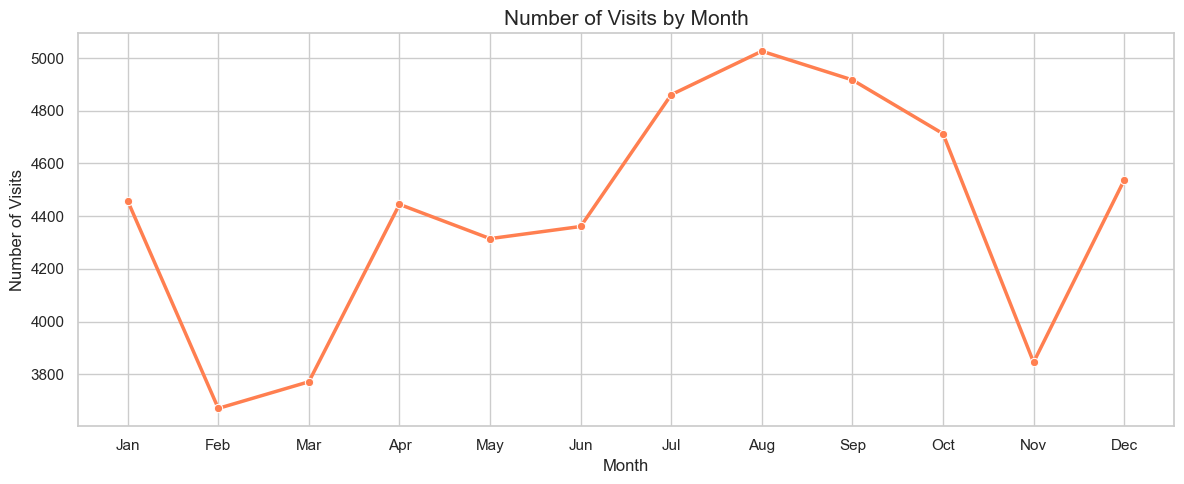

✅ Plot 5 saved!


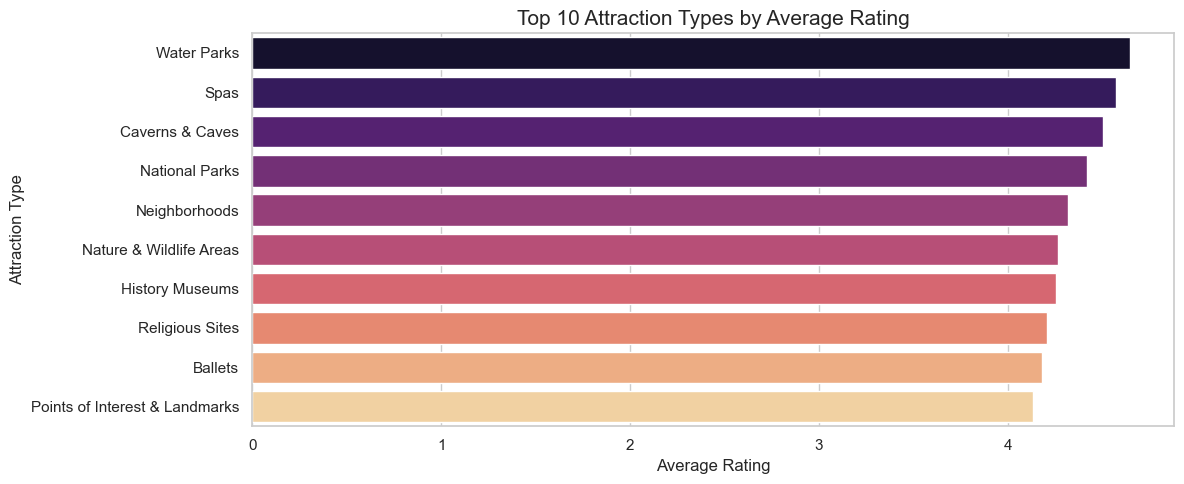

✅ Plot 6 saved!


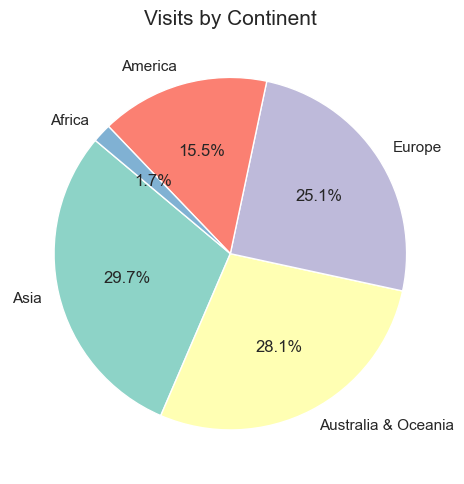

✅ Plot 7 saved!


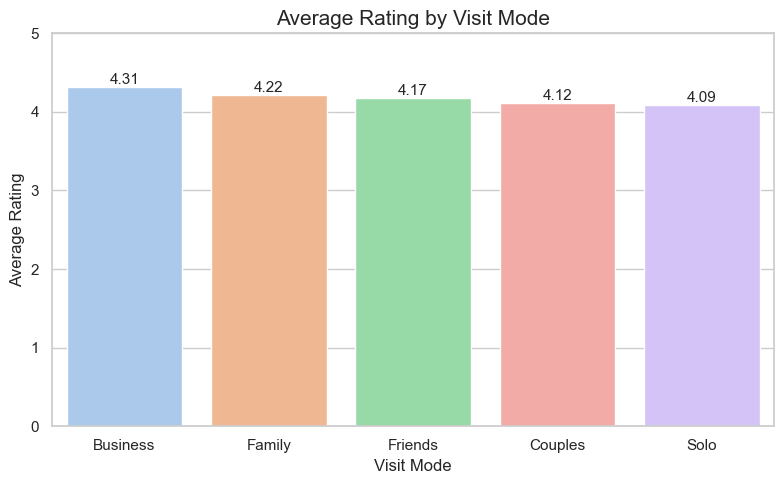

✅ Plot 8 saved!

✅ ALL 8 PLOTS COMPLETE!


In [2]:
# ============================================
# PLOT 1: Rating Distribution
# ============================================
plt.figure(figsize=(8, 5))
sns.countplot(data=master, x='Rating', palette='Blues')
plt.title('Distribution of Ratings', fontsize=15)
plt.xlabel('Rating')
plt.ylabel('Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height()):,}', 
                       (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('data/plot1_rating_distribution.png')
plt.show()
print("✅ Plot 1 saved!")

# ============================================
# PLOT 2: Visit Mode Distribution
# ============================================
plt.figure(figsize=(8, 5))
visit_counts = master['VisitModeName'].value_counts()
sns.barplot(x=visit_counts.index, y=visit_counts.values, palette='Set2')
plt.title('Visit Mode Distribution', fontsize=15)
plt.xlabel('Visit Mode')
plt.ylabel('Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height()):,}', 
                       (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('data/plot2_visit_mode.png')
plt.show()
print("✅ Plot 2 saved!")

# ============================================
# PLOT 3: Top 10 Countries by Visitors
# ============================================
plt.figure(figsize=(12, 5))
top_countries = master['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='coolwarm')
plt.title('Top 10 Countries by Number of Visits', fontsize=15)
plt.xlabel('Number of Visits')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('data/plot3_top_countries.png')
plt.show()
print("✅ Plot 3 saved!")

# ============================================
# PLOT 4: Top 10 Attraction Types
# ============================================
plt.figure(figsize=(12, 5))
top_types = master['AttractionType'].value_counts().head(10)
sns.barplot(x=top_types.values, y=top_types.index, palette='viridis')
plt.title('Top 10 Attraction Types by Visits', fontsize=15)
plt.xlabel('Number of Visits')
plt.ylabel('Attraction Type')
plt.tight_layout()
plt.savefig('data/plot4_attraction_types.png')
plt.show()
print("✅ Plot 4 saved!")

# ============================================
# PLOT 5: Visits by Month
# ============================================
plt.figure(figsize=(12, 5))
month_counts = master['VisitMonth'].value_counts().sort_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
sns.lineplot(x=month_names, y=month_counts.values, 
             marker='o', color='coral', linewidth=2.5)
plt.title('Number of Visits by Month', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Number of Visits')
plt.tight_layout()
plt.savefig('data/plot5_visits_by_month.png')
plt.show()
print("✅ Plot 5 saved!")

# ============================================
# PLOT 6: Average Rating by Attraction Type
# ============================================
plt.figure(figsize=(12, 5))
avg_rating = master.groupby('AttractionType')['Rating'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_rating.values, y=avg_rating.index, palette='magma')
plt.title('Top 10 Attraction Types by Average Rating', fontsize=15)
plt.xlabel('Average Rating')
plt.ylabel('Attraction Type')
plt.tight_layout()
plt.savefig('data/plot6_avg_rating_by_type.png')
plt.show()
print("✅ Plot 6 saved!")

# ============================================
# PLOT 7: Visits by Continent
# ============================================
plt.figure(figsize=(10, 5))
continent_counts = master['Continent'].value_counts()
plt.pie(continent_counts.values, labels=continent_counts.index,
        autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('Set3', len(continent_counts)))
plt.title('Visits by Continent', fontsize=15)
plt.tight_layout()
plt.savefig('data/plot7_continent_pie.png')
plt.show()
print("✅ Plot 7 saved!")

# ============================================
# PLOT 8: Average Rating by Visit Mode
# ============================================
plt.figure(figsize=(8, 5))
avg_rating_mode = master.groupby('VisitModeName')['Rating'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rating_mode.index, y=avg_rating_mode.values, palette='pastel')
plt.title('Average Rating by Visit Mode', fontsize=15)
plt.xlabel('Visit Mode')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', 
                       (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('data/plot8_rating_by_visitmode.png')
plt.show()
print("✅ Plot 8 saved!")

print("\n✅ ALL 8 PLOTS COMPLETE!")